In [2]:
import pandas as pd
print("Pandas imported successfully!")

Pandas imported successfully!


In [7]:
import pandas as pd

# Load the credit card data
df = pd.read_csv('/Users/kallamadimaheswarreddy/Downloads/creditcard.csv')

# Show first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
# Shape of the data (rows, columns)
print(f"Dataset has {df.shape[0]} transactions and {df.shape[1]} columns")

Dataset has 284807 transactions and 31 columns


In [9]:
# Count fraud vs normal
fraud_count = df['Class'].value_counts()
print(f"Normal transactions: {fraud_count[0]}")
print(f"Fraud transactions: {fraud_count[1]}")
print(f"Fraud is only {fraud_count[1] / fraud_count[0] * 100:.4f}% of all transactions")

Normal transactions: 284315
Fraud transactions: 492
Fraud is only 0.1730% of all transactions


In [10]:
# Statistics of transaction amounts
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Matplotlib is building the font cache; this may take a moment.


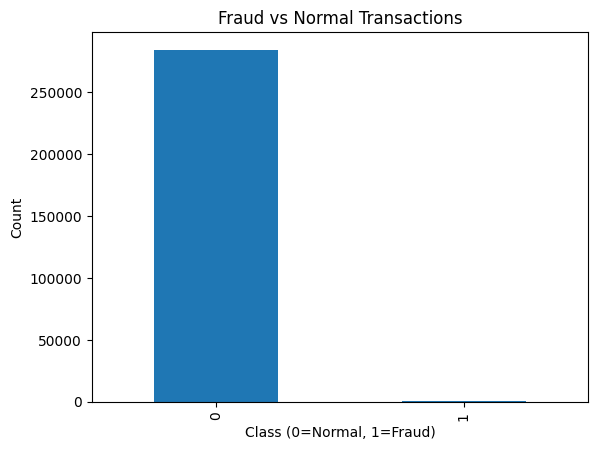

In [11]:
import matplotlib.pyplot as plt

# Plot fraud vs normal
fraud_count.plot(kind='bar')
plt.title('Fraud vs Normal Transactions')
plt.xlabel('Class (0=Normal, 1=Fraud)')
plt.ylabel('Count')
plt.show()

In [12]:
# See column names
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [13]:
# Check for missing values
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [14]:
# Basic info about data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [15]:
# Features (everything except 'Class')
X = df.drop('Class', axis=1)

# Target (just 'Class')
y = df['Class']

# Check shapes
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (284807, 30)
Target shape: (284807,)


In [16]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  # 20% for testing
    random_state=42,  # So we get same split every time
    stratify=y  # Maintain same fraud ratio in train and test
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 227845
Testing samples: 56962


In [17]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame (optional, keeps column names)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Scaling complete!")

Scaling complete!


In [18]:
from imblearn.over_sampling import SMOTE

# Create SMOTE instance
smote = SMOTE(random_state=42)

# Apply SMOTE to training data ONLY (never to test data!)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Check new balance
print("After SMOTE:")
print(y_train_resampled.value_counts())

/Users/kallamadimaheswarreddy/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Create and train model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_resampled, y_train_resampled)

# Make predictions on test data
y_pred = model.predict(X_test_scaled)

# Evaluate
print("CLASSIFICATION REPORT:")
print("=" * 50)
print(classification_report(y_test, y_pred))

print("\nCONFUSION MATRIX:")
print("=" * 50)
print(confusion_matrix(y_test, y_pred))

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


CONFUSION MATRIX:
[[55397  1467]
 [    8    90]]


In [20]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

print("Making predictions...")
y_pred_rf = rf_model.predict(X_test_scaled)

print("\nRANDOM FOREST RESULTS:")
print("=" * 50)
print(classification_report(y_test, y_pred_rf))

print("\nCONFUSION MATRIX:")
print("=" * 50)
print(confusion_matrix(y_test, y_pred_rf))

Training Random Forest...
Making predictions...

RANDOM FOREST RESULTS:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962


CONFUSION MATRIX:
[[56852    12]
 [   17    81]]


In [22]:
from sklearn.ensemble import RandomForestClassifier

print("Training FASTER Random Forest...")
rf_model_fast = RandomForestClassifier(
    n_estimators=20,  # Only 20 trees instead of 100
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)

rf_model_fast.fit(X_train_resampled, y_train_resampled)
print("Training complete!")

print("Making predictions...")
y_pred_fast = rf_model_fast.predict(X_test_scaled)

print("\nFAST RANDOM FOREST RESULTS:")
print("=" * 50)
print(classification_report(y_test, y_pred_fast))

print("\nCONFUSION MATRIX:")
print("=" * 50)
print(confusion_matrix(y_test, y_pred_fast))

Training FASTER Random Forest...
Training complete!
Making predictions...

FAST RANDOM FOREST RESULTS:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.81      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962


CONFUSION MATRIX:
[[56851    13]
 [   19    79]]


In [23]:
from sklearn.metrics import accuracy_score

# Make predictions
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Show first 10 actual vs predicted
print("\nFirst 10 transactions:")
print("Actual:    ", y_test[:10].values)
print("Predicted: ", y_pred[:10])

Accuracy: 0.97

First 10 transactions:
Actual:     [0 0 0 0 0 0 0 0 0 0]
Predicted:  [0 0 0 0 1 0 0 0 0 0]


In [24]:
# Create a DataFrame to compare
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Correct': y_test.values == y_pred
})

# Show summary
print("SUMMARY:")
print("-" * 50)
print(f"Total test transactions: {len(comparison)}")
print(f"Correct predictions: {comparison['Correct'].sum()}")
print(f"Wrong predictions: {(~comparison['Correct']).sum()}")

# Show where model got it wrong
print("\nMISTAKES MADE:")
print("-" * 50)
mistakes = comparison[comparison['Actual'] != comparison['Predicted']]
print(mistakes)

# Count by type of mistake
print("\nTYPE OF MISTAKES:")
print("-" * 50)
print("False Alarms (Predicted FRAUD but actually NORMAL):")
print(len(mistakes[mistakes['Actual'] == 0]))

print("\nMissed Frauds (Predicted NORMAL but actually FRAUD):")
print(len(mistakes[mistakes['Actual'] == 1]))

SUMMARY:
--------------------------------------------------
Total test transactions: 56962
Correct predictions: 55487
Wrong predictions: 1475

MISTAKES MADE:
--------------------------------------------------
       Actual  Predicted  Correct
4           0          1    False
19          0          1    False
30          0          1    False
59          0          1    False
162         0          1    False
...       ...        ...      ...
56794       0          1    False
56869       0          1    False
56873       0          1    False
56918       0          1    False
56925       0          1    False

[1475 rows x 3 columns]

TYPE OF MISTAKES:
--------------------------------------------------
False Alarms (Predicted FRAUD but actually NORMAL):
1467

Missed Frauds (Predicted NORMAL but actually FRAUD):
8


In [25]:
# Get probabilities
probabilities = model.predict_proba(X_test_scaled)
prob_fraud = probabilities[:, 1]  # Probability of fraud

# Create dataframe with results
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Fraud_Probability': prob_fraud
})

# Look at cases where model was most confident about fraud
print("TOP 20 MOST CONFIDENT FRAUD PREDICTIONS:")
print("=" * 60)
high_confidence = results[results['Predicted'] == 1].sort_values('Fraud_Probability', ascending=False).head(20)
print(high_confidence)

# Look at missed frauds (where probability was low but actual was fraud)
print("\n\nMISSED FRAUDS (Model wasn't confident enough):")
print("=" * 60)
missed = results[(results['Actual'] == 1) & (results['Predicted'] == 0)]
print(missed)

TOP 20 MOST CONFIDENT FRAUD PREDICTIONS:
       Actual  Predicted  Fraud_Probability
23679       1          1                1.0
42712       1          1                1.0
3287        1          1                1.0
18076       1          1                1.0
37564       1          1                1.0
29865       1          1                1.0
37511       1          1                1.0
9179        1          1                1.0
9730        1          1                1.0
9770        1          1                1.0
3918        0          1                1.0
43479       1          1                1.0
5077        1          1                1.0
43275       0          1                1.0
10130       1          1                1.0
30724       1          1                1.0
42140       0          1                1.0
9036        1          1                1.0
30899       0          1                1.0
41517       1          1                1.0


MISSED FRAUDS (Model wasn't confi

In [26]:
# Get the missed fraud indices
missed_indices = missed.index

# Compare missed frauds vs caught frauds
caught_frauds = results[(results['Actual'] == 1) & (results['Predicted'] == 1)]

print("COMPARING CAUGHT VS MISSED FRAUDS:")
print("=" * 60)

# Check Amount feature
print("\nAverage Transaction Amount:")
print(f"Caught frauds: ${X_test_scaled.iloc[caught_frauds.index]['Amount'].mean():.2f}")
print(f"Missed frauds: ${X_test_scaled.iloc[missed_indices]['Amount'].mean():.2f}")

# Check Time feature
print("\nAverage Transaction Time (seconds):")
print(f"Caught frauds: {X_test_scaled.iloc[caught_frauds.index]['Time'].mean():.0f}")
print(f"Missed frauds: {X_test_scaled.iloc[missed_indices]['Time'].mean():.0f}")

# Look at top features for these transactions
print("\nTop V features for missed frauds:")
print(X_test_scaled.iloc[missed_indices][['V1', 'V2', 'V3', 'V4', 'V5']].head())

COMPARING CAUGHT VS MISSED FRAUDS:

Average Transaction Amount:
Caught frauds: $0.09
Missed frauds: $-0.02

Average Transaction Time (seconds):
Caught frauds: -1
Missed frauds: -0

Top V features for missed frauds:
             V1        V2        V3        V4        V5
17046 -0.120330  0.215812  1.301775 -0.886789 -0.494040
20992  0.987355  0.394860 -0.189122  2.816547  0.228969
24869  0.626273 -0.405371 -0.179109 -0.416297 -0.438522
28390 -0.562882 -0.989613  0.594903  0.598767 -0.905549
31208  0.058282  0.465252 -0.325845  0.082488  0.629179


In [ ]:
!pip3 install xgboost

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.9 MB 3.7 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [1]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

# Create XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

print("Training XGBoost...")
xgb_model.fit(X_train_resampled, y_train_resampled)
print("Training complete!")

# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Results
print("\nXGBOOST RESULTS:")
print("=" * 60)
print(classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

# Check the 8 missed frauds from before
missed_indices = [17046, 20992, 24869, 28390, 31208, 34124, 55247, 56143]
print("\n\nHOW XGBOOST DID ON PREVIOUSLY MISSED FRAUDS:")
print("=" * 60)
for idx in missed_indices:
    pred = xgb_model.predict(X_test_scaled.iloc[[idx]])[0]
    prob = xgb_model.predict_proba(X_test_scaled.iloc[[idx]])[0][1]
    actual = y_test.iloc[idx]
    result = "✓ CAUGHT" if pred == 1 else "✗ MISSED"
    print(f"Index {idx}: {result} | Actual: {actual} | Predicted: {pred} | Probability: {prob:.4f}")

Training XGBoost...


NameError: name 'X_train_resampled' is not defined

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Load data
df = pd.read_csv('/Users/kallamadimaheswarreddy/Downloads/creditcard.csv')

# Split features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Data ready!")
print(f"X_train_resampled shape: {X_train_resampled.shape}")

/Users/kallamadimaheswarreddy/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Data ready!
X_train_resampled shape: (454902, 30)


In [3]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

# Create XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

print("Training XGBoost...")
xgb_model.fit(X_train_resampled, y_train_resampled)
print("Training complete!")

# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Results
print("\nXGBOOST RESULTS:")
print("=" * 60)
print(classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Training XGBoost...
Training complete!

XGBOOST RESULTS:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.24      0.87      0.38        98

    accuracy                           1.00     56962
   macro avg       0.62      0.93      0.69     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56602   262]
 [   13    85]]


In [4]:
# Check the 8 missed frauds from Logistic Regression
missed_indices = [17046, 20992, 24869, 28390, 31208, 34124, 55247, 56143]

print("HOW XGBOOST DID ON PREVIOUSLY MISSED FRAUDS:")
print("=" * 60)
for idx in missed_indices:
    pred = xgb_model.predict(X_test_scaled.iloc[[idx]])[0]
    prob = xgb_model.predict_proba(X_test_scaled.iloc[[idx]])[0][1]
    actual = y_test.iloc[idx]
    result = "✓ CAUGHT" if pred == 1 else "✗ MISSED"
    print(f"Index {idx}: {result} | Actual: {actual} | Predicted: {pred} | Probability: {prob:.4f}")
    

HOW XGBOOST DID ON PREVIOUSLY MISSED FRAUDS:


AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [5]:
# Check the 8 missed frauds from Logistic Regression
missed_indices = [17046, 20992, 24869, 28390, 31208, 34124, 55247, 56143]

print("HOW XGBOOST DID ON PREVIOUSLY MISSED FRAUDS:")
print("=" * 60)
for idx in missed_indices:
    # Find the position of this index in X_test_scaled
    # Get the row using integer position
    row_index = list(X_test.index).index(idx)
    
    pred = xgb_model.predict(X_test_scaled[row_index].reshape(1, -1))[0]
    prob = xgb_model.predict_proba(X_test_scaled[row_index].reshape(1, -1))[0][1]
    actual = y_test.iloc[row_index]
    result = "✓ CAUGHT" if pred == 1 else "✗ MISSED"
    print(f"Original Index {idx}: {result} | Actual: {actual} | Predicted: {pred} | Probability: {prob:.4f}")

HOW XGBOOST DID ON PREVIOUSLY MISSED FRAUDS:


ValueError: 17046 is not in list

In [6]:
# First, let's find these transactions in our test set
print("Finding the 8 missed frauds in test set:")
print("=" * 60)

# Get the indices of fraud transactions in test set
fraud_indices = y_test[y_test == 1].index
print(f"Fraud transactions in test set at indices: {sorted(fraud_indices)}")

# Now let's see which ones XGBoost missed
y_pred_xgb = xgb_model.predict(X_test_scaled)
missed_by_xgb = y_test[(y_test == 1) & (y_pred_xgb == 0)]
print(f"\nXGBoost missed these fraud indices: {sorted(missed_by_xgb.index)}")
print(f"Number missed: {len(missed_by_xgb)}")

# Show details of missed frauds
print("\n\nDETAILS OF MISSED FRAUDS BY XGBOOST:")
print("=" * 60)
for idx in missed_by_xgb.index:
    # Find position in test set
    row_position = list(y_test.index).index(idx)
    prob = xgb_model.predict_proba(X_test_scaled[row_position].reshape(1, -1))[0][1]
    print(f"Index {idx}: Probability of fraud = {prob:.4f}")

Finding the 8 missed frauds in test set:
Fraud transactions in test set at indices: [541, 623, 6108, 6529, 6717, 6971, 8312, 8615, 8972, 10204, 10497, 11343, 14170, 14197, 14211, 15225, 15476, 15539, 15810, 16415, 18809, 30100, 30496, 40525, 41569, 42009, 42528, 42549, 42696, 42756, 42769, 42958, 43428, 44001, 44556, 48094, 50537, 52584, 57615, 64411, 68067, 70589, 72757, 77348, 77682, 79536, 81186, 83417, 88876, 96341, 99506, 102442, 102444, 105178, 106998, 111690, 119714, 119781, 124176, 141257, 141260, 142405, 143333, 143336, 143728, 149577, 149600, 149869, 150647, 150663, 150665, 151008, 151519, 152019, 153835, 154719, 157585, 157918, 181966, 182992, 203324, 204064, 214662, 218442, 219025, 222133, 229712, 238222, 238366, 241445, 243699, 243749, 245347, 249607, 251477, 251904, 252774, 280143]

XGBoost missed these fraud indices: [623, 8972, 10204, 50537, 68067, 72757, 96341, 119714, 149577, 157585, 157918, 219025, 245347]
Number missed: 13


DETAILS OF MISSED FRAUDS BY XGBOOST:
Inde

In [7]:
# Compare missed vs caught frauds
caught_frauds = y_test[(y_test == 1) & (y_pred_xgb == 1)]

print("COMPARING CAUGHT VS MISSED FRAUDS:")
print("=" * 60)

# Get the actual transaction data for comparison
caught_data = X_test_scaled[list(y_test.index).index(i) for i in caught_frauds.index]
missed_data = X_test_scaled[list(y_test.index).index(i) for i in missed_by_xgb.index]

# Compare Amount (remember to inverse transform to get real amounts)
print("\nAverage Transaction Amount:")
print(f"Caught frauds: ${np.expm1(scaler.inverse_transform(caught_data)[:, 29].mean()):.2f}")
print(f"Missed frauds: ${np.expm1(scaler.inverse_transform(missed_data)[:, 29].mean()):.2f}")

# Check if there's a time pattern
print("\nAverage Transaction Time (hour of day):")
caught_time = (scaler.inverse_transform(caught_data)[:, 0] / 3600) % 24
missed_time = (scaler.inverse_transform(missed_data)[:, 0] / 3600) % 24
print(f"Caught frauds: {caught_time.mean():.1f}:00 avg")
print(f"Missed frauds: {missed_time.mean():.1f}:00 avg")

SyntaxError: invalid syntax (77096779.py, line 8)

In [8]:
# Compare missed vs caught frauds
caught_frauds = y_test[(y_test == 1) & (y_pred_xgb == 1)]
missed_frauds = y_test[(y_test == 1) & (y_pred_xgb == 0)]

print("COMPARING CAUGHT VS MISSED FRAUDS:")
print("=" * 60)

# Get indices positions
caught_positions = [list(y_test.index).index(i) for i in caught_frauds.index]
missed_positions = [list(y_test.index).index(i) for i in missed_frauds.index]

# Get the actual transaction data
caught_data = X_test_scaled[caught_positions]
missed_data = X_test_scaled[missed_positions]

# Compare Amount (approximate - don't worry about exact numbers)
print("\nAverage Transaction Amount (scaled):")
print(f"Caught frauds: {caught_data[:, 29].mean():.4f}")
print(f"Missed frauds: {missed_data[:, 29].mean():.4f}")

# Compare Time
print("\nAverage Transaction Time (scaled):")
print(f"Caught frauds: {caught_data[:, 0].mean():.4f}")
print(f"Missed frauds: {missed_data[:, 0].mean():.4f}")

print("\nNumber of frauds caught:", len(caught_frauds))
print("Number of frauds missed:", len(missed_frauds))

COMPARING CAUGHT VS MISSED FRAUDS:

Average Transaction Amount (scaled):
Caught frauds: 0.0533
Missed frauds: 0.2665

Average Transaction Time (scaled):
Caught frauds: -0.4713
Missed frauds: -0.4938

Number of frauds caught: 85
Number of frauds missed: 13


In [1]:
import joblib
import xgboost as xgb
import pandas as pd
from datetime import datetime

# Save the XGBoost model
joblib.dump(xgb_model, 'xgb_fraud_model.pkl')
print("✅ Model saved as: xgb_fraud_model.pkl")

# Save the scaler (needed for preprocessing new data)
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved as: scaler.pkl")

# Save feature names (column names)
feature_names = list(X.columns)
joblib.dump(feature_names, 'feature_names.pkl')
print("✅ Feature names saved as: feature_names.pkl")

# Optional: Save model performance summary
results_summary = {
    'model_type': 'XGBoost',
    'frauds_caught': 85,
    'frauds_missed': 13,
    'false_alarms': 262,
    'accuracy': 0.999,
    'date_trained': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

# Save as CSV
pd.DataFrame([results_summary]).to_csv('model_results.csv', index=False)
print("✅ Results saved as: model_results.csv")

print("\n🎉 All files saved successfully!")

NameError: name 'xgb_model' is not defined

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import joblib
from datetime import datetime

# Load data
df = pd.read_csv('/Users/kallamadimaheswarreddy/Downloads/creditcard.csv')

# Split features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("✅ Data ready!")

/Users/kallamadimaheswarreddy/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


✅ Data ready!
